In [1]:
import numpy as np
import pandas as pd

# =============================================================================
# Which run to read.
#
# Same switches, and the same naming rule, as manuscript_figures_v1 and
# DMC_sebset_freq2.7.1_c_overlap_flag -- the point of this notebook is to open exactly the
# CSVs behind the observed-vs-expected figure, so the pairs listed here are the pairs plotted
# there and nothing is recomputed.
# =============================================================================
DMC_MIN_PERCENT = {'IN': 1.0, 'PR': 5.0, 'RT': 5.0}
TOP_N_PAIRS = 20
CSV_VERSION = 'v17'
USE_TOP_DDE_PAIRS = True
NON_OVERLAPPING = False        # False -> the "_with_overlap" CSVs

PROTEINS = {                   # protein -> (file stem, label used in the figures)
    'IN': ('integrase_all_probabilities', 'INSTI'),
    'PR': ('protease_all_probabilities', 'PI'),
    'RT': ('reverseTranscriptase_both_probabilities', 'NRTI/NNRTI'),
}
CATS = [('Gain_of_function', 'gain of fitness'), ('rescue', 'rescue'),
        ('compensatory', 'compensatory'), ('non_compensatory', 'non-compensatory')]


def csv_name(stem, protein):
    """Probability-CSV name, following DMC_sebset_freq2.7.1's out_name()."""
    tags = [f"{stem}_{CSV_VERSION}"]
    if USE_TOP_DDE_PAIRS:
        tags.append(f"topdde_{DMC_MIN_PERCENT[protein]:g}pct")
        if TOP_N_PAIRS is not None:
            tags.append(f"top{TOP_N_PAIRS}")
    if not NON_OVERLAPPING:
        tags.append("with_overlap")
    return "_".join(tags) + ".csv"


DFS = {}
for _p, (_stem, _lab) in PROTEINS.items():
    DFS[_p] = pd.read_csv(csv_name(_stem, _p))
    print(f"{_p}: {csv_name(_stem, _p)}")


IN: integrase_all_probabilities_v17_topdde_1pct_top20_with_overlap.csv
PR: protease_all_probabilities_v17_topdde_5pct_top20_with_overlap.csv
RT: reverseTranscriptase_both_probabilities_v17_topdde_5pct_top20_with_overlap.csv


In [2]:
# =============================================================================
# Where the carriers of each pair sit.
#
# The probability CSVs already carry this: for every pair they hold one row per epistasis
# category, with num_seqs = how many sequences of the alignment fall in that category for
# that pair, and num_with_DMC = how many of those actually carry the double mutation. The
# four categories partition the alignment, so the four num_with_DMC values add up to the
# pair's total carrier count (asserted below) -- no energies need to be recomputed here.
#
# Read the table by row: of the sequences that carry this pair, what share of them landed in
# a background the model calls gain of fitness, rescue, compensatory or non-compensatory.
# That is the reverse of the observed-vs-expected figure, which asks the question by
# category; here it is asked by pair.
# =============================================================================
KEYS = [k for k, _ in CATS]
LABELS = dict(CATS)


def carrier_breakdown(df):
    """One row per pair: total carriers, then how they split over the four categories."""
    wide = df[df['epistasis_subset'].isin(KEYS)].pivot(
        index='mutation_pair', columns='epistasis_subset', values='num_with_DMC')[KEYS]
    total = (df[df['epistasis_subset'] == 'Total']
             .set_index('mutation_pair')['num_with_DMC'].reindex(wide.index))
    assert (wide.sum(axis=1) == total).all(), "categories do not add up to the total carriers"

    out = pd.DataFrame({'carriers': total})
    for k in KEYS:
        out[f'{LABELS[k]} n'] = wide[k]
        out[f'{LABELS[k]} %'] = (100 * wide[k] / total).round(1)
    return out.sort_values('carriers', ascending=False)


BREAKDOWN = {}
for p, (stem, lab) in PROTEINS.items():
    t = carrier_breakdown(DFS[p])
    BREAKDOWN[p] = t
    t.to_csv(f'carrier_category_breakdown_{p}.csv')

    pooled = t[[c for c in t.columns if c.endswith(' n')]].sum()
    share = (100 * pooled / t['carriers'].sum()).round(1)
    print(f"\n===== {p} ({lab}): {len(t)} pairs, {t['carriers'].sum():,} carrier sequences")
    print('  all pairs pooled: ' + '   '.join(
        f'{LABELS[k]} {share[f"{LABELS[k]} n"]:.1f}%' for k in KEYS))
    print(f'  written to carrier_category_breakdown_{p}.csv')

pd.set_option('display.width', 200, 'display.max_columns', 20)
BREAKDOWN['RT']



===== IN (INSTI): 20 pairs, 808 carrier sequences
  all pairs pooled: gain of fitness 59.2%   rescue 29.6%   compensatory 8.9%   non-compensatory 2.4%
  written to carrier_category_breakdown_IN.csv

===== PR (PI): 16 pairs, 12,327 carrier sequences
  all pairs pooled: gain of fitness 68.6%   rescue 3.8%   compensatory 23.4%   non-compensatory 4.2%
  written to carrier_category_breakdown_PR.csv

===== RT (NRTI/NNRTI): 20 pairs, 42,241 carrier sequences
  all pairs pooled: gain of fitness 72.2%   rescue 3.3%   compensatory 22.5%   non-compensatory 2.0%
  written to carrier_category_breakdown_RT.csv


,carriers,gain of fitness n,gain of fitness %,rescue n,rescue %,compensatory n,compensatory %,non-compensatory n,non-compensatory %
mutation_pair,,,,,,,,,
M41L-T215Y,6114,5223,85.4,577,9.4,304,5.0,10,0.2
M41L-L210W,4939,4345,88.0,36,0.7,540,10.9,18,0.4
L210W-T215Y,4775,4251,89.0,10,0.2,500,10.5,14,0.3
D67N-K70R,2943,2595,88.2,22,0.7,209,7.1,117,4.0
M41L-E44D,2177,1365,62.7,0,0.0,801,36.8,11,0.5
E44D-T215Y,2109,1357,64.3,0,0.0,745,35.3,7,0.3
D67N-K219Q,2082,1794,86.2,114,5.5,156,7.5,18,0.9
K70R-K219Q,2016,1753,87.0,146,7.2,95,4.7,22,1.1
H208Y-R211K,1792,1037,57.9,14,0.8,733,40.9,8,0.4


In [3]:
# The other two tables. Sorted by carrier count, so the pairs at the top are the ones the
# observed-vs-expected figure draws as the largest markers.
display(BREAKDOWN['IN'])
display(BREAKDOWN['PR'])


,carriers,gain of fitness n,gain of fitness %,rescue n,rescue %,compensatory n,compensatory %,non-compensatory n,non-compensatory %
mutation_pair,,,,,,,,,
G140S-Q148H,221,122,55.2,99,44.8,0,0.0,0,0.0
S119P-T122I,81,44,54.3,26,32.1,9,11.1,2,2.5
T97A-S119R,57,37,64.9,8,14.0,11,19.3,1,1.8
S119G-T122I,54,39,72.2,13,24.1,2,3.7,0,0.0
E157Q-K160Q,50,24,48.0,26,52.0,0,0.0,0,0.0
E11D-S24N,50,29,58.0,9,18.0,12,24.0,0,0.0
T97A-Y143R,39,27,69.2,2,5.1,5,12.8,5,12.8
K219N-N222K,26,10,38.5,14,53.8,2,7.7,0,0.0
D6E-E10D,24,10,41.7,5,20.8,9,37.5,0,0.0


,carriers,gain of fitness n,gain of fitness %,rescue n,rescue %,compensatory n,compensatory %,non-compensatory n,non-compensatory %
mutation_pair,,,,,,,,,
L63P-L90M,1626,1270,78.1,0,0.0,352,21.6,4,0.2
A71V-L90M,1031,824,79.9,22,2.1,145,14.1,40,3.9
V77I-I93L,994,505,50.8,80,8.0,342,34.4,67,6.7
E35D-M36I,941,552,58.7,82,8.7,245,26.0,62,6.6
L10I-V82A,878,757,86.2,15,1.7,87,9.9,19,2.2
I54V-V82A,877,655,74.7,103,11.7,105,12.0,14,1.6
L10I-I54V,841,725,86.2,11,1.3,98,11.7,7,0.8
M36I-I62V,817,476,58.3,11,1.3,221,27.1,109,13.3
I54V-A71V,791,671,84.8,8,1.0,95,12.0,17,2.1


saved carrier_category_breakdown.png / .pdf


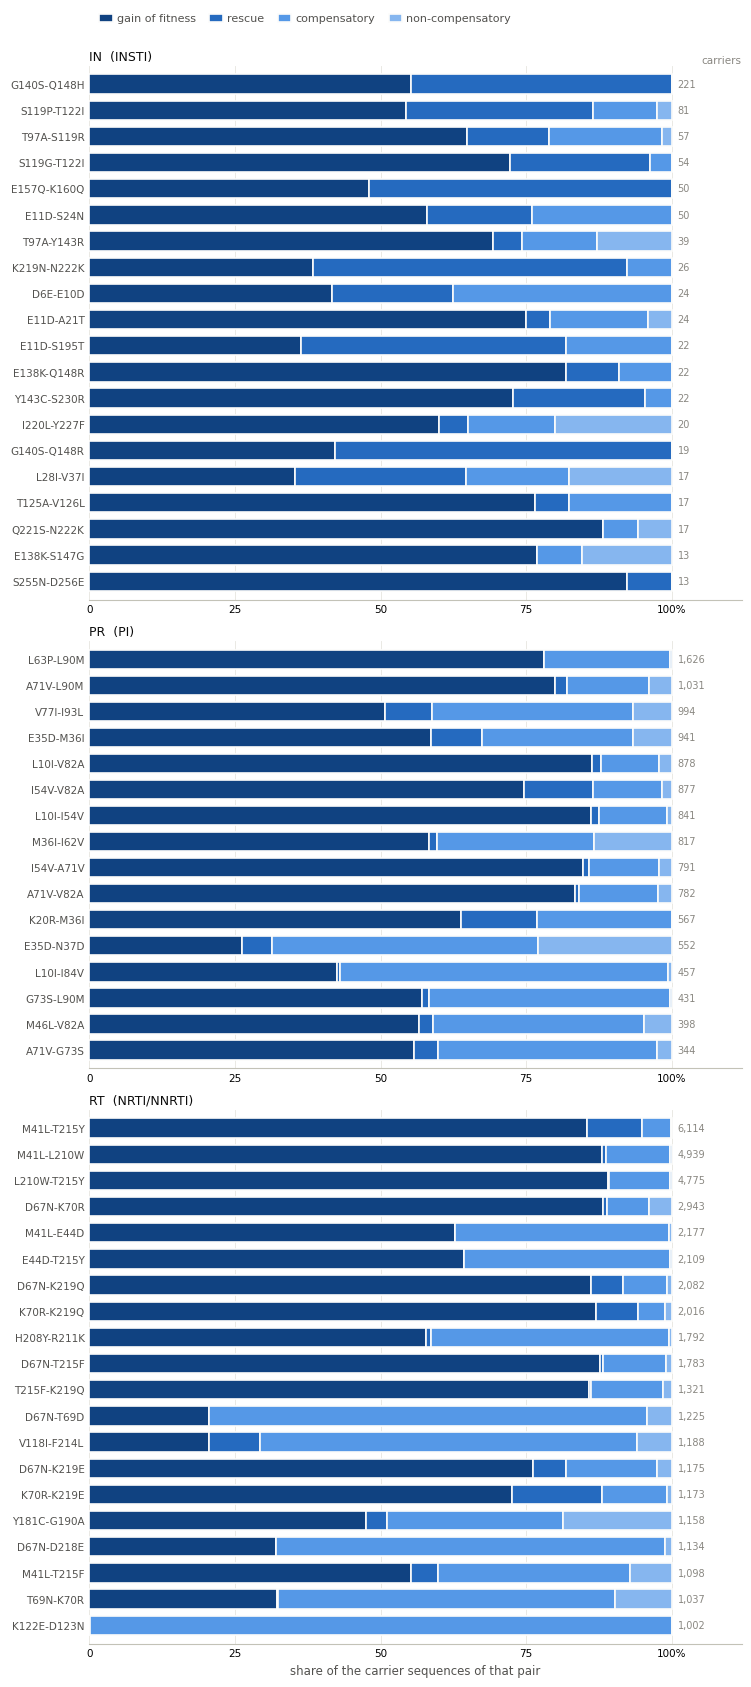

In [4]:
import matplotlib.pyplot as plt

# =============================================================================
# The same tables as one figure: each bar is a pair, split into where its carriers sit.
#
# The four categories are ordered (gain of fitness > rescue > compensatory >
# non-compensatory), so they take one blue ramp light-to-dark rather than four unrelated
# hues -- the shade itself carries the ranking. Bars are 100% wide; the carrier count is
# printed at the end of each bar, since a percentage of 13 sequences and a percentage of
# 6,000 are not the same evidence.
# =============================================================================
SURFACE, INK, INK2, MUTED, GRID, BASE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e6e5df', '#c3c2b7'
RAMP = ['#104281', '#256abf', '#5598e7', '#86b6ef']      # gof -> non-compensatory

n_rows = [len(BREAKDOWN[p]) for p in PROTEINS]
fig, axes = plt.subplots(3, 1, figsize=(7.4, 0.26 * sum(n_rows) + 2.2),
                         gridspec_kw={'height_ratios': n_rows}, layout='constrained')

for ax, (p, (stem, lab)) in zip(axes, PROTEINS.items()):
    t = BREAKDOWN[p].iloc[::-1]                          # largest carrier count on top
    y = np.arange(len(t))
    left = np.zeros(len(t))
    for k, colour in zip(KEYS, RAMP):
        w = 100 * t[f'{LABELS[k]} n'] / t['carriers']
        ax.barh(y, w, left=left, height=0.74, color=colour, edgecolor=SURFACE, linewidth=1.2,
                zorder=3, label=LABELS[k] if ax is axes[0] else None)
        left += w.values
    for i, (name, row) in enumerate(t.iterrows()):
        ax.text(101, i, f"{int(row['carriers']):,}", va='center', fontsize=7, color=MUTED)

    ax.set_yticks(y, t.index, fontsize=7.5, color=INK2)
    ax.set_xlim(0, 112)
    ax.set_ylim(-0.7, len(t) - 0.3)
    ax.set_xticks([0, 25, 50, 75, 100], ['0', '25', '50', '75', '100%'], fontsize=7.5)
    ax.set_title(f'{p}  ({lab})', fontsize=9, color=INK, loc='left', pad=4)
    ax.tick_params(length=0)
    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_color(BASE)
    ax.grid(axis='x', color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)

axes[0].legend(loc='lower left', bbox_to_anchor=(0, 1.06), ncol=4, frameon=False,
               fontsize=8, labelcolor=INK2, handlelength=1.2, handletextpad=0.4,
               columnspacing=1.2)
axes[-1].set_xlabel('share of the carrier sequences of that pair', fontsize=8.5, color=INK2)
fig.text(1.0, 1.0, 'carriers', ha='right', va='bottom', fontsize=7.5, color=MUTED,
         transform=axes[0].transAxes)

fig.savefig('carrier_category_breakdown.png', dpi=400, bbox_inches='tight', pad_inches=0.02,
            facecolor=SURFACE)
fig.savefig('carrier_category_breakdown.pdf', bbox_inches='tight', pad_inches=0.02,
            facecolor=SURFACE)
print('saved carrier_category_breakdown.png / .pdf')
plt.show()
